# SMART dimension and text-conditioning decision

Reproducible summary of the strict 256-d audit and the selected 960-d learned text residual. The promotion criterion is end-to-end reciprocal rank on session-grouped held-out examples; candidate-pool misses contribute zero.

**Decision:** retain the 960-d acoustic contract and ship optional trusted text conditioning.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt

RESULTS = Path('smart-conditioning-results.json')
if not RESULTS.exists():
    RESULTS = Path('docs/experiments/smart-conditioning-results.json')
data = json.loads(RESULTS.read_text())
data['dataset'], data['selected_960_phone_contract']['architecture']

({'database_rows': 862,
  'usable_library_tracks': 860,
  'listening_events': 3960,
  'sessions': 145,
  'positive_next_track_examples': 1519,
  'mixed_context_training_examples': 3038,
  'folds': 4,
  'split_unit': 'session'},
 'local 4-play GRU + 30/365-day taste centroids + frozen 960-d acoustic scorer + learned bounded 384-d MiniLM residual')

In [2]:
d256 = data['strict_256_phone_contract']
d960 = data['selected_960_phone_contract']
cold = d960['first_open_cold_start']
comparison = {
    '256 audio': d256['audio_only']['mrr_end_to_end'],
    '256 + text': d256['trusted_text']['mrr_end_to_end'],
    '960 history audio': d960['audio_only']['mrr_end_to_end'],
    '960 history + text': d960['trusted_text']['mrr_end_to_end'],
    '960 first-open audio': cold['audio_only']['mrr_end_to_end'],
    '960 first-open + text': cold['trusted_text']['mrr_end_to_end'],
}
comparison

{'256 audio': 0.024885551937745182,
 '256 + text': 0.0440115016134648,
 '960 history audio': 0.06214700255285525,
 '960 history + text': 0.08555368829031514,
 '960 first-open audio': 0.061986958858103125,
 '960 first-open + text': 0.07836606660498395}

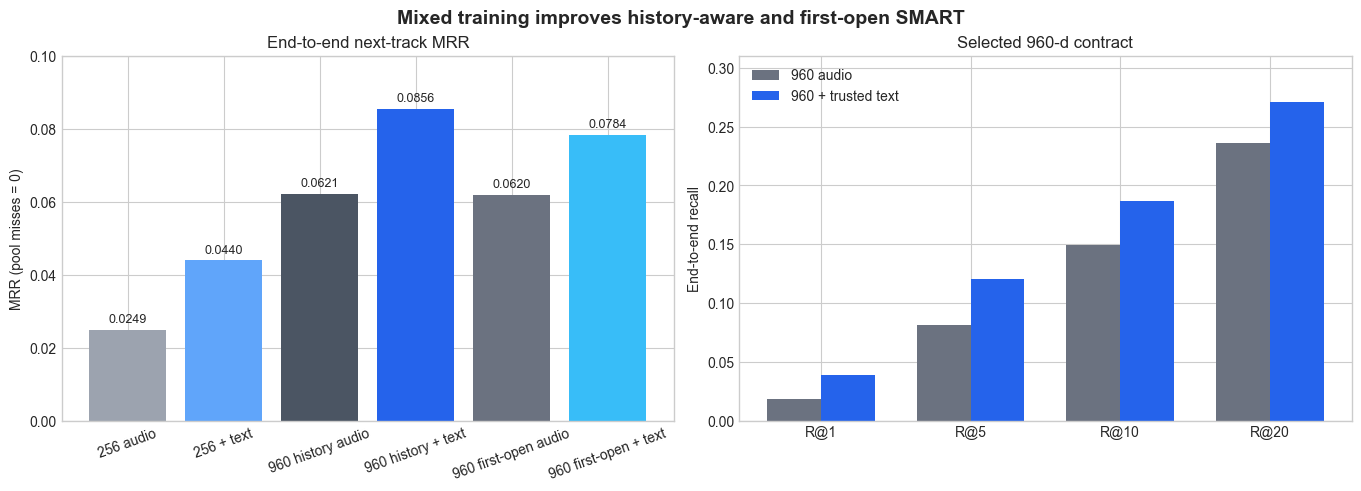

PosixPath('smart-conditioning-mrr.png')

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True)
colors = ['#9CA3AF', '#60A5FA', '#4B5563', '#2563EB', '#6B7280', '#38BDF8']
bars = axes[0].bar(comparison.keys(), comparison.values(), color=colors)
axes[0].set_title('End-to-end next-track MRR')
axes[0].set_ylabel('MRR (pool misses = 0)')
axes[0].set_ylim(0, 0.10)
axes[0].tick_params(axis='x', rotation=20)
for bar, value in zip(bars, comparison.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, value + 0.002, f'{value:.4f}', ha='center', fontsize=9)

ks = [1, 5, 10, 20]
audio = [d960['audio_only'][f'recall_at_{k}_end_to_end'] for k in ks]
text = [d960['trusted_text'][f'recall_at_{k}_end_to_end'] for k in ks]
x = range(len(ks))
width = 0.36
axes[1].bar([i - width/2 for i in x], audio, width, label='960 audio', color='#6B7280')
axes[1].bar([i + width/2 for i in x], text, width, label='960 + trusted text', color='#2563EB')
axes[1].set_title('Selected 960-d contract')
axes[1].set_ylabel('End-to-end recall')
axes[1].set_xticks(list(x), [f'R@{k}' for k in ks])
axes[1].set_ylim(0, 0.31)
axes[1].legend(frameon=False)
fig.suptitle('Mixed training improves history-aware and first-open SMART', fontsize=14, fontweight='bold')
figure_path = RESULTS.parent / 'smart-conditioning-mrr.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
plt.show()
figure_path

In [4]:
cf = d960['counterfactuals']
counterfactual_summary = {
    'correct trusted text MRR': d960['trusted_text']['mrr_end_to_end'],
    'missing text MRR': cf['missing_text_mrr_end_to_end'],
    'missing max logit delta': cf['missing_text_max_abs_logit_delta'],
    'title genre injection MRR': cf['title_genre_injection_mrr_end_to_end'],
    'title top-1 agreement vs correct': cf['title_genre_injection_top1_vs_correct'],
    'explicit wrong genre MRR': cf['wrong_genre_mrr_end_to_end'],
    'wrong genre top-1 agreement vs audio': cf['wrong_genre_top1_vs_audio'],
}
counterfactual_summary

{'correct trusted text MRR': 0.08555368829031514,
 'missing text MRR': 0.06214700255285525,
 'missing max logit delta': 0.0,
 'title genre injection MRR': 0.08555368829031514,
 'title top-1 agreement vs correct': 1.0,
 'explicit wrong genre MRR': 0.06539368103561777,
 'wrong genre top-1 agreement vs audio': 0.8940092165898618}

## Interpretation

- Mixed training raises history-aware 960-d end-to-end MRR by 37.7% and first-open MRR by 26.4%.
- Missing text is an exact acoustic fallback.
- Genre text injected into a title is an exact no-op because titles are excluded.
- The 256-d component metrics are strong, but its end-to-end result remains 33.1% below the 960 scorer on the same 256 candidate pool.
- History-aware fold MRR spans 0.0579–0.0943 and first-open fold MRR spans 0.0679–0.0866, so the result still needs multiple listeners and physical-phone profiling.